# Lane Detection: Mask White Pixels in a Colour Image

This notebook runs a **colour selection** step for lane detection directly on the colour image. White lane paint is bright in **all three** colour channels, so a pixel counts as white only when its red, green **and** blue values are all above a threshold. This rejects bright but coloured areas, such as a yellow line or a blue sky, which can look just as bright as white in a grayscale image.

**What it does:**
1. Loads the colour road image `image_lane_c.jpg`.
2. Builds a **white mask**: pixels whose R, G and B values are all at or above `WHITE_THRESHOLD` are kept and all others are set to black.
3. Shows the original image, the binary mask and the kept colour pixels side by side.
4. Plots a histogram of each colour channel with the threshold marked.
5. Compares several thresholds (`COMPARE_THRESHOLDS`: 220, 200, 180) with a reusable function that shows each result next to its histograms.
6. Saves the result for `WHITE_THRESHOLD` as `image_lane_white_color.jpg` and each comparison result as `image_lane_white_color_<threshold>.jpg`.

**How it is implemented:**
- The image is loaded with `cv2.imread`, which returns **BGR**, and converted to **RGB** once, so the channel order is clear in all the following code.
- The white test is a single expression, `np.all(image >= threshold, axis=-1)`, meaning "keep only if every channel is bright enough".
- The input image is never modified in place, and all thresholds are named constants in the configuration cell.
- The binary mask and the kept colour pixels are shown separately, so you can see both where and what was kept.
- Missing files and failed saves raise clear errors.

## 1. Imports

- `cv2` (OpenCV): image I/O and colour conversion
- `matplotlib`: displaying images
- `numpy`: array operations
- `pathlib`: file paths that work on any OS

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Configuration

`WHITE_THRESHOLD` is the minimum value that **each** of R, G and B must reach for a pixel to count as white. We use 220, because the threshold comparison in section 6 shows it gives the cleanest lanes for this image. Lower values keep more pixels, including light grey asphalt and sky. Higher values keep only the brightest, purest white.

`COMPARE_THRESHOLDS` lists the thresholds compared in section 6.

In [2]:
INPUT_PATH = Path("image_lane_c.jpg")
OUTPUT_PATH = INPUT_PATH.with_name("image_lane_white_color.jpg")

WHITE_THRESHOLD = 220  # 0-255: minimum value for every channel (R, G and B)
COMPARE_THRESHOLDS = (220, 200, 180)  # thresholds compared side by side in section 6

CHANNEL_NAMES = ("Red", "Green", "Blue")
CHANNEL_COLORS = ("tab:red", "tab:green", "tab:blue")

## 3. Load the image

`cv2.imread` returns `None` instead of raising an error when a file is missing, so we check for that.

> ⚠️ OpenCV loads images in **BGR** order. We convert to **RGB** right away, so channel 0 is red, 1 is green and 2 is blue in all the following code.

In [3]:
image_bgr = cv2.imread(str(INPUT_PATH), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise FileNotFoundError(f"Could not read image: {INPUT_PATH.resolve()}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

height, width, channels = image_rgb.shape
print(f"Colour image: {width}x{height} px, {channels} channels, dtype={image_rgb.dtype}")

Colour image: 960x540 px, 3 channels, dtype=uint8


## 4. Mask the white pixels

`white_mask(image, threshold)` returns a 2D boolean array that is `True` only where **all** channels are at or above the threshold:

$$\text{white} = (R \ge t) \land (G \ge t) \land (B \ge t)$$

We then keep the original colours of the white pixels and set everything else to black. `np.where` builds a new image, so `image_rgb` stays unchanged and can be reused for other thresholds.

In [4]:
def white_mask(image_rgb: np.ndarray, threshold: int) -> np.ndarray:
    """Return a boolean mask that is True where every colour channel is >= threshold."""
    return np.all(image_rgb >= threshold, axis=-1)


def apply_mask(image_rgb: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Keep the pixels where mask is True and set all others to black."""
    return np.where(mask[..., np.newaxis], image_rgb, 0).astype(np.uint8)


mask = white_mask(image_rgb, WHITE_THRESHOLD)
image_white = apply_mask(image_rgb, mask)

kept = int(mask.sum())
print(f"Threshold: {WHITE_THRESHOLD} (per channel)")
print(f"White pixels kept: {kept:,} of {mask.size:,} ({kept / mask.size:.2%})")

Threshold: 220 (per channel)
White pixels kept: 3,102 of 518,400 (0.60%)


## 5. Compare the results

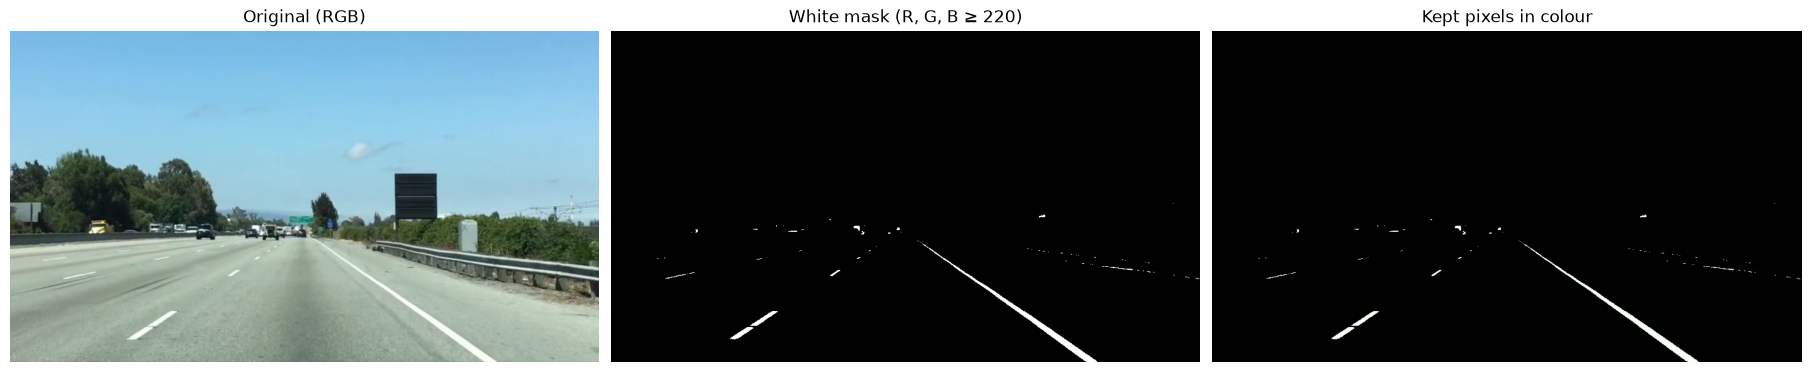

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), layout="constrained")

axes[0].imshow(image_rgb)
axes[0].set_title("Original (RGB)")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"White mask (R, G, B ≥ {WHITE_THRESHOLD})")

axes[2].imshow(image_white)
axes[2].set_title("Kept pixels in colour")

for ax in axes:
    ax.axis("off")

plt.show()

### Colour channel histograms

One histogram per channel. The dashed line marks the threshold, and a pixel is kept only if it is to the right of the line in **all three** histograms.

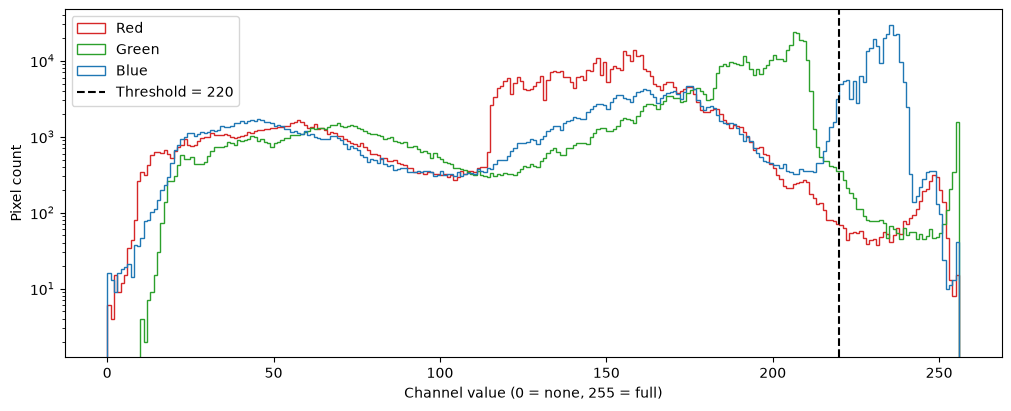

In [6]:
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")

for i, (name, color) in enumerate(zip(CHANNEL_NAMES, CHANNEL_COLORS)):
    ax.hist(image_rgb[..., i].ravel(), bins=256, range=(0, 256),
            histtype="step", color=color, label=name)

ax.axvline(WHITE_THRESHOLD, color="black", linestyle="--", label=f"Threshold = {WHITE_THRESHOLD}")
ax.set_xlabel("Channel value (0 = none, 255 = full)")
ax.set_ylabel("Pixel count")
ax.set_yscale("log")
ax.legend()

plt.show()

## 6. Compare several thresholds

`compare_thresholds` gives one row per threshold:
- **left:** the kept white pixels in colour for that threshold
- **right:** the three channel histograms with the kept range (≥ threshold) shaded

It returns a dictionary that maps each threshold to its result image, so you can reuse the images later. Change `COMPARE_THRESHOLDS` in section 2 to try other values.

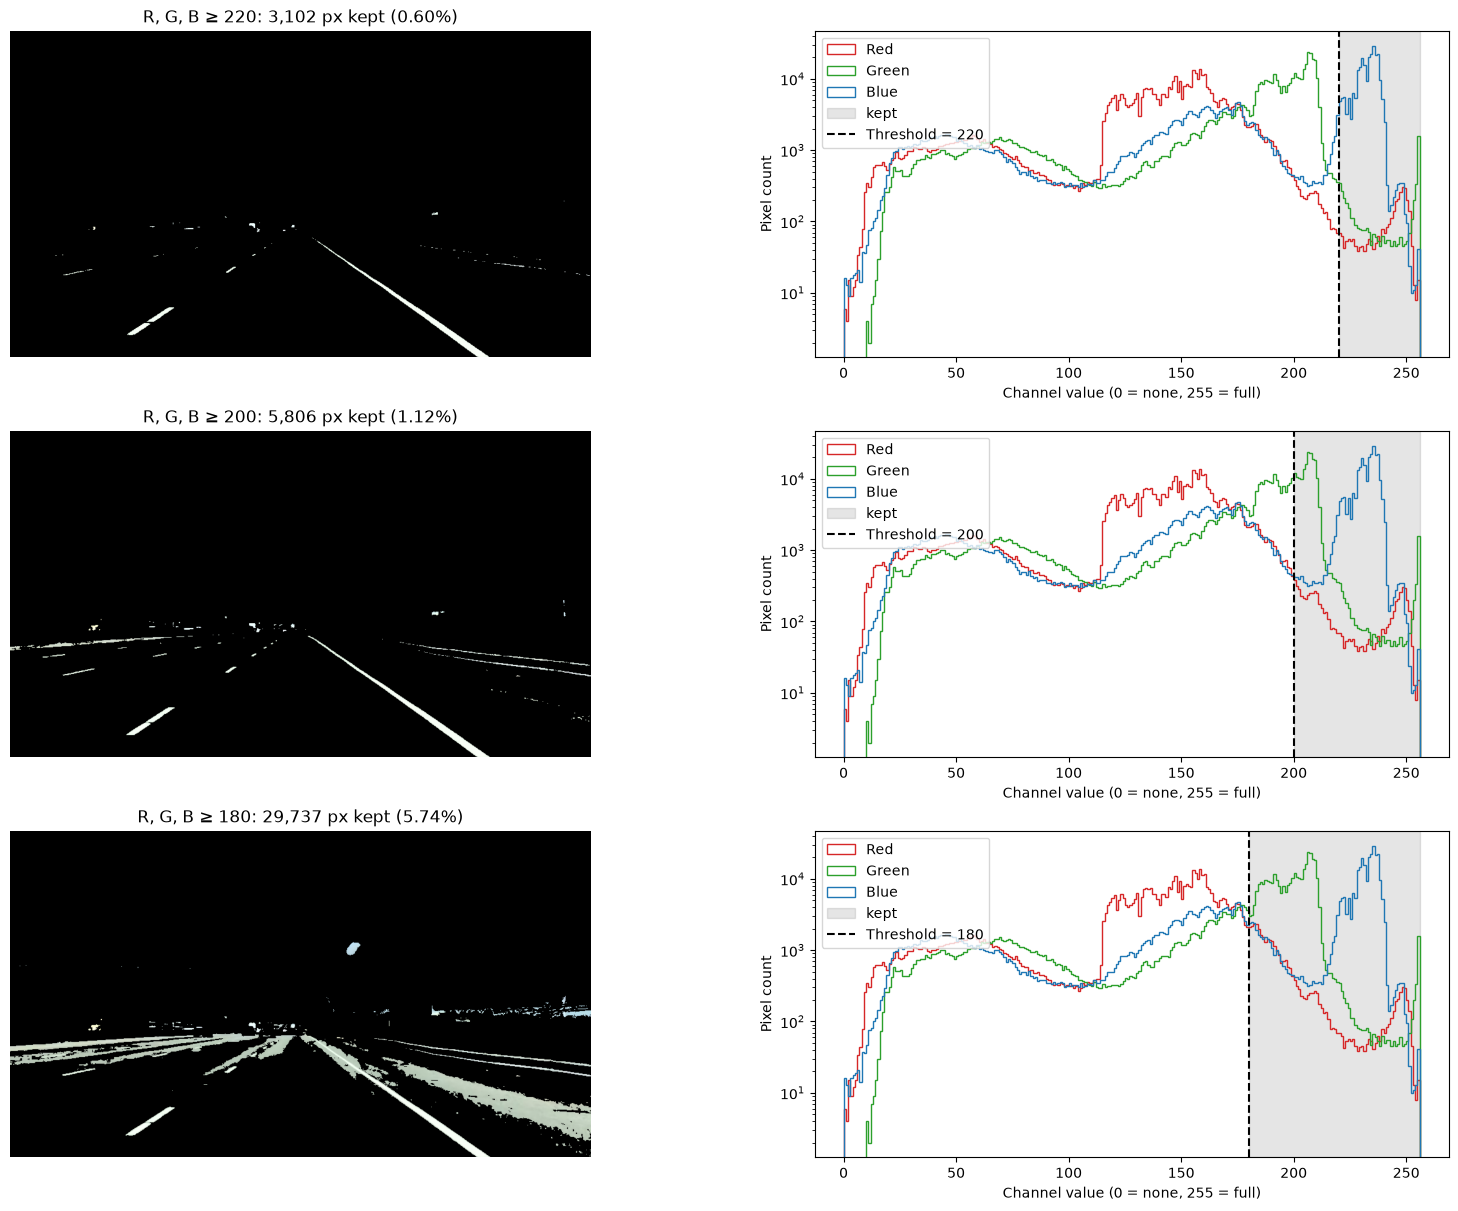

In [7]:
def compare_thresholds(
    image_rgb: np.ndarray, thresholds: tuple[int, ...] = (220, 200, 180)
) -> dict[int, np.ndarray]:
    """Plot the white-pixel result and channel histograms for each threshold and return the results."""
    results: dict[int, np.ndarray] = {}
    fig, axes = plt.subplots(
        len(thresholds), 2, figsize=(16, 4 * len(thresholds)),
        layout="constrained", squeeze=False, width_ratios=(1.4, 1),
    )

    for (ax_img, ax_hist), threshold in zip(axes, thresholds):
        mask = white_mask(image_rgb, threshold)
        results[threshold] = apply_mask(image_rgb, mask)

        ax_img.imshow(results[threshold])
        ax_img.set_title(f"R, G, B ≥ {threshold}: {int(mask.sum()):,} px kept ({mask.mean():.2%})")
        ax_img.axis("off")

        for i, (name, color) in enumerate(zip(CHANNEL_NAMES, CHANNEL_COLORS)):
            ax_hist.hist(image_rgb[..., i].ravel(), bins=256, range=(0, 256),
                         histtype="step", color=color, label=name)
        ax_hist.axvspan(threshold, 256, color="black", alpha=0.1, label="kept")
        ax_hist.axvline(threshold, color="black", linestyle="--", label=f"Threshold = {threshold}")
        ax_hist.set_xlabel("Channel value (0 = none, 255 = full)")
        ax_hist.set_ylabel("Pixel count")
        ax_hist.set_yscale("log")
        ax_hist.legend(loc="upper left")

    plt.show()
    return results


threshold_results = compare_thresholds(image_rgb, COMPARE_THRESHOLDS)

### Results for 220, 200 and 180

> These notes are for `image_lane_c.jpg` with the thresholds 220, 200 and 180. If you change `COMPARE_THRESHOLDS` or use another image, look at the new plots and read them the same way.

| Threshold | Pixels kept | Observation |
|---|---|---|
| 220 | 3,102 (0.60%) | Both lanes next to the car are clean and complete. There's very little noise: a few dots near the horizon and a faint line along the right road edge. |
| 200 | 5,806 (1.12%) | It also picks up the lane markings farther away on the left, but the metal guardrail on the right shows up as long lines too. |
| 180 | 29,737 (5.74%) | Much too low. Large areas of light grey asphalt, the road edge and part of the cloud are kept. |

**What the histograms show:** the **red** channel decides the result. The sky is bright in blue (peak at about 235) but low in red, so the "all channels" rule rejects it. The asphalt, on the other hand, is a light grey with red values up to about 200. Once the threshold drops below 200 the asphalt starts to pass all three tests, which is why 180 lets so much road through.

**Best value for this image: about 220.** It gives the cleanest lane lines with almost no noise. Use about 200 if you also want the distant lane markings and can accept the guardrail. Don't go below about 200 for this image.

**Compared with the grayscale notebook:** the colour rule at 220 keeps almost exactly the same pixels as grayscale at 240 (3,102 vs. 3,106). The real advantage of the colour rule shows on images with coloured bright areas, such as yellow lines, which it can tell apart from white.

## 7. Save the results

First the result for `WHITE_THRESHOLD` is saved, then one image per value in `COMPARE_THRESHOLDS`, e.g. `image_lane_white_color_200.jpg`.

> ⚠️ `cv2.imwrite` expects **BGR**, so we convert back from RGB before saving. It returns `False` when saving fails, so we check the result.

In [8]:
def save_rgb(path: Path, image_rgb: np.ndarray) -> None:
    """Save an RGB image with OpenCV, raising an error if it fails."""
    if not cv2.imwrite(str(path), cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)):
        raise OSError(f"Could not write image: {path.resolve()}")
    print(f"Saved {path.resolve()}")


save_rgb(OUTPUT_PATH, image_white)

for threshold, result in threshold_results.items():
    save_rgb(INPUT_PATH.with_name(f"image_lane_white_color_{threshold}.jpg"), result)

Saved /workspaces/ml-autonomous-systems/lane_detection_color/image_lane_white_color.jpg
Saved /workspaces/ml-autonomous-systems/lane_detection_color/image_lane_white_color_220.jpg
Saved /workspaces/ml-autonomous-systems/lane_detection_color/image_lane_white_color_200.jpg
Saved /workspaces/ml-autonomous-systems/lane_detection_color/image_lane_white_color_180.jpg
